# CVaR-Assited Custom Penalty Function for Constrained Optimization

ここでは、[Lee & Lau (2026)](https://arxiv.org/abs/2604.20088)の内容を理解し、その実装を通してQamomileの使い方を学びましょう。

## 制約つき最適化のためのCVaRアシスト型のカスタムペナルティ関数

### 問題背景

制約つき最適化問題をQUBOに変換し、量子アルゴリズムで解くことを考えましょう。
不等式制約 $h_j(x) \leq 0 \ (j=1, \dots, k)$ を扱う方法として、スラック変数 $y_\ell$ を導入する手法があります。
そして $\lambda_j (h_j(x) + \sum_{\ell=0}^{N-1}2^\ell y_\ell)^2$ という項を損失関数に加えるのが、一般的な手法として考えられてきました。
しかしこの手法には、次のような欠点があります。

1. 最適化ランドスケープの悪化: 実行可能解と実行不可能解を隔てる明確な境界が存在しません。制約条件が満たされている場合にペナルティ項をゼロにするような $y$ は確かに存在します。しかし制約条件が満たされていてもペナルティ項を大きくするような別の $y$ の値も存在します。このため探索空間が、本来は探索する必要のない冗長な $y$ の組合せにより溢れることになります。このようにして、最適化ランドスケープをさらに悪化させる副作用を持ちます。
2. 現実の量子ハードウェアの限界: スラック変数を二進数で展開するために、$\lceil \log_2 s_j \rceil$ 個の追加の量子ビットが必要となります (ここで $s_j$ は $h_j$ の取りうる最大値)。これにより、より大きな探索空間が生み出され、不毛のプラトーのような変分量子アルゴリズムの最適化の困難さが生まれます。さらに現在の量子ハードウェアは、利用可能な量子ビット数が限られています。そして利用する量子ビットが多くなるほど、ノイズの影響もより受けることになります。

### 先行研究

同じ著者らの先行研究に、[Lee & Lau (2025)](https://arxiv.org/abs/2504.12611)があります。
ここではスラック変数を導入せず、非線形のカスタムペナルティ関数 $\xi$ を用いる手法が考案されました。
これを用いて、損失関数は次のように書かれます。

$$
\mathcal{L}_\mathrm{custom} 
= f(x) + \sum_{j=1}^k \lambda_j \xi[h_j(x)] \tag{1}
$$

ここで $f(x)$ は目的関数です。
$\xi$ は適当に定めることができますが、典型的な選択としてはヘヴィサイドの階段関数 $\Theta$ が考えられます。

$$
\Theta [h_j(x)] 
= \left\{ \begin{array}{ll}
1 & h_j(x) > 0 \\
0 & h_j(x) \leq 0
\end{array}
\right. \tag{2}
$$

これにより、制約が満たされない $h_j(x)>0$ の時のみ、ペナルティ関数が値を持つことになります。
式(1)に対応するハミルトニアンは

$$
H 
= H_f + \sum_{j=1}^k \lambda_j \xi(H_j) \tag{3}
$$

となります。
ここで $H_f, H_j$ はそれぞれ、目的関数 $f(x)$ と制約 $h_j(x)$ に対応したハミルトニアンです。
これらハミルトニアンは、Pauli-Zの1次 $Z_n$ と2次 $Z_n Z_m$ の項からなります。
ここまでで、式(1)を最小化する解を得るには、変分法を用いることで $H$ の基底状態エネルギーを求めることと等価であることがわかります。
これは、変分アンザッツ回路により準備された状態を $\vert \psi(\boldsymbol{\theta}) \rangle$ とすると、期待値$\langle \psi(\boldsymbol{\theta}) \vert H \vert \psi(\boldsymbol{\theta}) \rangle$ を最小化することを意味します。
$\langle H \rangle$は期待値であることから、次のように式変形ができます。

$$
\langle H \rangle 
= \langle H_f \rangle + \sum_{j=1}^k \lambda_j \langle \xi(H_j) \rangle \tag{4}
$$

しかし、$\xi$ は非線形であるため、$\langle Z_n \rangle$ や $\langle Z_n Z_m \rangle$ の和に容易に分解することができません。
先行研究では完全対角化による評価を用いた手法により、1つの制約あたりの変数の数を $t$ として $\mathcal{O}(2^t)$のような指数関数的なコストがかかります。
そこで[Lee & Lau (2026)](https://arxiv.org/abs/2604.20088)では、その改良手法を示しました。

### 有限サンプリングとCVaR

期待値の推定器を $\hat{E}$ のように書くことにしましょう。
量子回路から多数回のサンプリングを行ったとき、$i$ 番目の固有状態を得た確率を $p_i$ とすると、この推定器は

$$
\hat{E} (\boldsymbol{\theta}) 
= \sum_{i=0}^{2^n-1} \mathcal{L}(x(\boldsymbol{\theta}=i)) p_i \tag{5}
$$

のように与えられます。
$\mathcal{L}(x(\boldsymbol{\theta})=i)$は、$i$ 番目の固有状態に対する損失関数の値を表します。 
$M$ を総測定回数、$m_i$ を固有状態 $i$ がサンプリングされた回数とすれば、$p_i = m_i / M$ のように求めることができます。
以上から、(5)式は

$$
\hat{E} (\boldsymbol{\theta}) 
= \frac{1}{M} \sum_{m=1}^M \mathcal{L} (x^{(m)} (\boldsymbol{\theta})) \tag{6}
$$

のように書くこともできます。
ここで $x^{(m)}$ は $m$ 回目の測定から得られた解であり、$\mathcal{L} (x^{(m)} (\boldsymbol{\theta}))$ はその解から計算される損失関数の値です。
このように書き換えることで、期待値の推定が固定された測定回数 $M$ にのみ依存する形となり、先ほどの指数的な計算コストを用いる必要がなくなりました。  
これに加え、[Lee & Lau (2026)](https://arxiv.org/abs/2604.20088)では Conditional Value-at-Risk (CVaR) 法も活用しています。
CVaR法は、[Barkoutsos et al. (2020)](https://quantum-journal.org/papers/q-2020-04-20-256/)で導入された、対角ハミルトニアンをより効率的にサンプリングする手法です。
量子回路から $M$ 回のサンプルを抽出することを考えましょう。
そのときに抽出された解を $x^{(m)}$ のように書くことにします。
これらを $\mathcal{L}(x^{(1)}) \leq \mathcal{L}(x^{(2)}) \leq \cdots \leq \mathcal{L}(x^{(M)})$のように昇順に並べかえ、下位 $\lceil \alpha M \rceil$個のみを用いて期待値を計算します。

$$
\mathrm{CVaR} (\alpha; \boldsymbol{\theta}) 
= \frac{1}{\lceil \alpha M \rceil} \sum_{m=1}^{\lceil \alpha M \rceil} \mathcal{L}(x^{(m)} (\boldsymbol{\theta})) \tag{7}
$$

この $\alpha$ は信頼水準と呼ばれ、$0 < \alpha <1$ の範囲から選びます。
$\alpha=1$ のとき、CVaRはオリジナルの期待値 $\langle H \rangle$を計算することに一致します。
このようにすることで最適化ランドスケープをより滑らかにすることができ、ノイズ耐性も向上することが示されています。

### 多次元ナップサック問題

[Lee & Lau (2026)](https://arxiv.org/abs/2604.20088)では、多次元ナップサック問題を用いてこの手法の有効性を検証しています。
多次元ナップサック問題とは、以下のようなものです。

$$
\max \qquad \sum_{i=i}^n v_i x_i \tag{8}
$$

$$
\begin{align}
\mathrm{s.t.} \qquad & \sum_{i=1}^n w_{ij} x_i \leq W_j, \qquad j=1, \dots, d \tag{9} \\
& x_i \in \{0, 1\}, \qquad i=1, \dots, n \tag{10}
\end{align}
$$

ここで $x_i$ は $i$ 番目のアイテムを用いるかどうかを表す決定変数、$v_i$ は $i$ 番目のアイテムの価値、$w_{ij}$ は $i$ 番目のアイテムの $j$ 次元目の重さ、$W_j$ は $j$ 番目の次元における重さの上限を表します。
$d$ 個の制約が存在することから、この問題は標準的なナップサック問題よりも難しい問題であると考えられています。

## 実装

[Lee & Lau (2026)](https://arxiv.org/abs/2604.20088)で示された手法をQamomileを用いて実装し、解いてみましょう。
具体的には、Variational Quantum Eigensolver (VQE) を実装することで、次の損失関数の最小値を求めます。

$$
\mathcal{L}_\mathrm{MDKP} (x) 
= - \sum_{i=1}^n v_i x_i + \sum_{j=1}^d \sum_{i=1}^n \lambda_j \Theta \left( \sum_{i=1}^n w_{ij} x_i - W_j\right) \tag{11}
$$

$v_i, w_{ij}, W_j$をインスタンスデータとして、次のように実装しておきましょう。

In [1]:
def custom_loss_mdkp(x, instance_data, lambdas):
    values = instance_data["v"]
    weights = instance_data["w"]
    capacities = instance_data["W"]
    obj = - values @ x
    penalties = lambdas @ (weights @ x > capacities).astype(int)
    return obj + penalties

次に、VQE ansatzとして、単一層の Hardware Efficient Ansatz (HEA) を用いることにしましょう。

$$
\vert \psi (\boldsymbol{\theta}) \rangle 
= \bigotimes_{i=1}^n R_Y (\theta_{n+i}) \bigotimes_{i=1}^{n-1} CZ_{i, i+1} \bigotimes_{i=1}^n R_Y (\theta_i) \tag{12}
$$

Qamomileを用い、(12)式を実装します。

In [5]:
import qamomile.circuit as qmc
from qamomile.circuit.algorithm.basic import cz_entangling_layer, ry_layer

@qmc.qkernel
def hea(n: qmc.UInt, thetas: qmc.Vector[qmc.Float]) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(n, name="q")
    # for i in range(n):
    #     q[i] = qmc.ry(q[i], thetas[i])
    q = ry_layer(q, thetas, 0)
    q = cz_entangling_layer(q)
    q = ry_layer(q, thetas, n)
    return qmc.measure(q)

量子回路が正しく実装できているかを確認してみましょう。
ここでは簡単のため、量子ビット数を3として可視化を行います。

In [6]:
from qamomile.qiskit import QiskitTranspiler

transpiler = QiskitTranspiler()
num_qubits = 3
exe = transpiler.transpile(hea, bindings={"n": num_qubits}, parameters=["thetas"])
print(exe.quantum_circuit)

TypeError: Argument 'offset' must be a Handle instance, got <class 'int'>

問題インスタンスや種々のパラメータを定義しましょう。

In [7]:
import numpy as np

seed = 42
rng = np.random.default_rng(seed)
num_qubits = 5
inst_v = rng.random(num_qubits)
inst_w = rng.random((num_qubits, num_qubits))
inst_W = num_qubits * rng.random(num_qubits) / 2.0
instance_data = {"v": inst_v, "w": inst_w, "W": inst_W}
lambdas = np.array([1.0] * num_qubits)
num_params = 2 * num_qubits
thetas0 = rng.uniform(0.0, np.pi, num_params)
max_iter = 100
num_shots = 256

In [8]:
def cost_function(thetas, alpha):
    exe = transpiler.transpile(hea, bindings={"n": num_qubits}, parameters=["thetas"])
    job = exe.sample(transpiler.executor(), shots=num_shots, bindings={"thetas": thetas})
    result = job.result()
    temp_sums = 0.0
    losses = []
    occurrences = []
    xs = []
    for x_result, occur in result.results:
        loss = custom_loss_mdkp(x_result, instance_data, lambdas)
        losses.append(loss)
        occurrences.append(occur)
        xs.append(x_result)
        
    zip_lists = zip(losses, occurrences, xs)
    zip_sort = sorted(zip_lists)
    losses, occurrences, xs = zip(*zip_sort)
    
    num_samples_cvar = int(np.ceil(alpha*num_shots))
    losses_sort = []
    xs_sort = []
    for loss, occur, x_result in zip_sort:
        losses_sort += [loss] * occur
        xs_sort += [x_result] * occur
    losses_cvar = losses_sort[:num_samples_cvar]
    cvar_value = np.sum(losses_cvar) / num_samples_cvar
    return cvar_value

In [9]:
from scipy.optimize import minimize

alphas = np.arange(0.1, 1.01, 0.2)

cost_histories = []
for alpha in alphas:
    cost_history = []
    def cost_callback(thetas):
        cost_history.append(cost_function(thetas, alpha))
    
    result_iter = minimize(cost_function, thetas0, method="Powell", args=(alpha, ), options={"maxiter": max_iter, "xtol": 1e-8}, callback=cost_callback)
    cost_histories.append(cost_history)

print(cost_histories)

TypeError: Argument 'offset' must be a Handle instance, got <class 'int'>

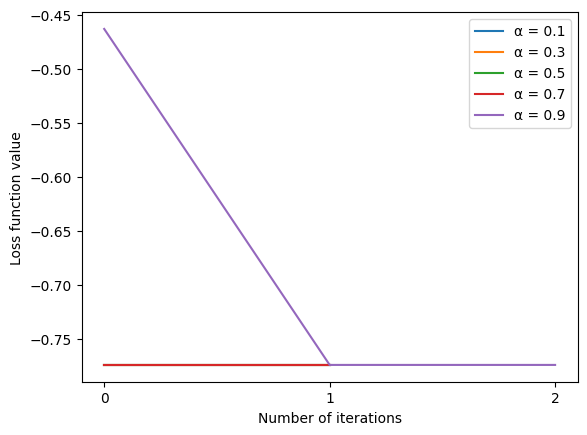

In [7]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

fig, ax = plt.subplots()
for i, cost_result in enumerate(cost_histories):
    ax.plot(cost_result, label="α = {:.1f}".format(alphas[i]))
ax.legend(loc=0)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_xlabel("Number of iterations")
ax.set_ylabel("Loss function value")
plt.show()